In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [3]:
# 나눔고딕 폰트 다운로드 및 설치
!apt-get update -qq
!apt-get install -qq fonts-nanum

# 설치된 폰트 목록 확인
!fc-list | grep "Nanum"

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 123621 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf: NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Bold,나눔스퀘어라운드 Bold:style=Bold,Regular
/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf: NanumGothicCoding,나눔고딕코딩:style=Bold
/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf: NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Regular,나눔스퀘어라운드 Regular:style=Regular
/usr/share/fonts/truetype/nanum/NanumSquareB.ttf: NanumSquare,나눔스퀘어,NanumSquare Bold,나눔스퀘어 Bold:style=Bold
/usr/share/fo

In [4]:
!fc-list | grep "Nanum"

/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf: NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Bold,나눔스퀘어라운드 Bold:style=Bold,Regular
/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf: NanumGothicCoding,나눔고딕코딩:style=Bold
/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf: NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Regular,나눔스퀘어라운드 Regular:style=Regular
/usr/share/fonts/truetype/nanum/NanumSquareB.ttf: NanumSquare,나눔스퀘어,NanumSquare Bold,나눔스퀘어 Bold:style=Bold
/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf: NanumBarunGothic,나눔바른고딕:style=Regular
/usr/share/fonts/truetype/nanum/NanumGothic.ttf: NanumGothic,나눔고딕:style=Regular
/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf: NanumGothicCoding,나눔고딕코딩:style=Regular
/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf: NanumBarunGothic,나눔바른고딕:style=Bold
/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf: NanumGothic,나눔고딕:style=Bold
/usr/share/fonts/truetype/nanum/NanumSquareR.ttf: NanumSquare,나눔스퀘어:style=Regular
/us

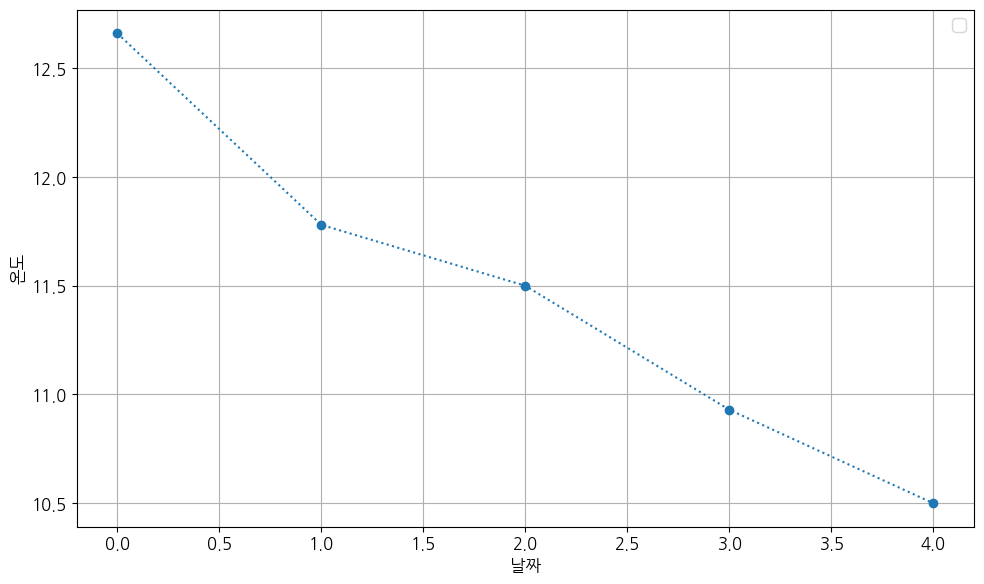

In [5]:
fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', # ttf 파일이 저장되어 있는 경로
    name='NanumGothic')                        # 원하는 폰트 설정
fm.fontManager.ttflist.insert(0, fe)              # Matplotlib에 폰트 추가

plt.rcParams.update({'font.size': 12, 'font.family': 'NanumGothic'}) # 폰트 설정

temperatures = [12.66, 11.78, 11.5, 10.93, 10.5]
times = range(len(temperatures))

plt.figure(figsize=(10, 6))
plt.plot(times, temperatures, marker='o', linestyle=':')

plt.xlabel('날짜')
plt.ylabel('온도')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# 550

## 데이터 가져오기

In [6]:
df5502021 = pd.read_excel('/content/drive/MyDrive/erp/5502021.xlsx')

In [7]:
df5502022 = pd.read_excel('/content/drive/MyDrive/erp/5502022.xlsx')

In [8]:
df5502023 = pd.read_excel('/content/drive/MyDrive/erp/5502023.xlsx')

In [9]:
df5502024 = pd.read_excel('/content/drive/MyDrive/erp/5502024.xlsx')

In [10]:
df5502022.head()

,매출채권상세조회(S),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,매출채권번호,매출채권순번,주문처,주문처명,납품처,납품처명,매출채권형태,매출채권형태명,매출일,품목,...,예외여부,수출여부,수주번호,수주순번,출하번호,출하순번,발행처명,발행처,품목그룹,품목그룹명
3,BN20220108077,1,AE000002,화성대리점,BLS00000,롯데슈퍼,S001,국내매출,2022-01-08 00:00:00,8809009552143,...,N,N,SN20220106023,1300,DN20220108077,1,화성대리점,AE000002,00,두부류
4,BN20220110077,4,AD000001,원주대리점,BLS00000,롯데슈퍼,S001,국내매출,2022-01-10 00:00:00,8809009552143,...,N,N,SN20220108017,1600,DN20220110078,4,원주대리점,AD000001,00,두부류


In [11]:
df1 = df5502021.rename(columns=df5502021.iloc[2])
df1 = df1.drop(df1.index[0:3])
df2 = df5502022.rename(columns=df5502022.iloc[2])
df2 = df2.drop(df2.index[0:3])
df3 = df5502023.rename(columns=df5502023.iloc[2])
df3 = df3.drop(df3.index[0:3])
df4 = df5502024.rename(columns=df5502024.iloc[2])
df4 = df4.drop(df4.index[0:3])

In [12]:
df2023 = df3.sort_values(by='매출일')
df2023 = df2023.groupby(['매출일'])['매출수량'].sum().reset_index()


In [13]:

df2023['week'] = df2023['매출일'].dt.isocalendar().week
df2023['weekday'] = df2023['매출일'].dt.weekday
df2023.drop(df2023.index[0],inplace=True)
df2023.reset_index(drop=True,inplace=True)
df2023


,매출일,매출수량,week,weekday
0,2023-01-02,20818,1,0
1,2023-01-03,22232,1,1
2,2023-01-04,23097,1,2
3,2023-01-05,23878,1,3
4,2023-01-06,24349,1,4
...,...,...,...,...
354,2023-12-27,38879,52,2
355,2023-12-28,28749,52,3
356,2023-12-29,48375,52,4
357,2023-12-30,52330,52,5


In [14]:
df2023.to_csv('df2023.csv',index=False)

In [15]:
df1.reset_index(drop=True, inplace=True)
df2.reset_index(drop=True, inplace=True)
df3.reset_index(drop=True, inplace=True)
df4.reset_index(drop=True, inplace=True)

In [16]:
df1['매출일'] = pd.to_datetime(df1['매출일'])
df2['매출일'] = pd.to_datetime(df2['매출일'])
df3['매출일'] = pd.to_datetime(df3['매출일'])
df4['매출일'] = pd.to_datetime(df4['매출일'])

In [17]:
df1 = df1[['매출일','매출수량','총매출채권금액']]
df2 = df2[['매출일','매출수량','총매출채권금액']]
df3 = df3[['매출일','매출수량','총매출채권금액']]
df4 = df4[['매출일','매출수량','총매출채권금액']]

## 데이터 병합

In [18]:
df = pd.concat([df1,df2,df3,df4])

In [19]:
df = df.sort_values(by='매출일')

In [20]:
zero_index = df[df['매출수량']==0].index
df.drop(zero_index,inplace=True)

In [21]:
df['단가'] = df['총매출채권금액'] // df['매출수량']

In [22]:
df

,매출일,매출수량,총매출채권금액,단가
3054,2021-01-01,30,44460,1482
15781,2021-01-01,1704,2487840,1460
27,2021-01-01,40,59280,1482
4648,2021-01-01,204,297840,1460
12351,2021-01-01,1,1482,1482
...,...,...,...,...
7456,2024-09-06,3,6258,2086
9668,2024-09-06,200,294000,1470
8904,2024-09-06,50,101500,2030
8551,2024-09-06,4,8624,2156


In [23]:
pre_grouped = df.groupby(['매출일']).agg({'매출수량':'sum',
                                       '단가':lambda x: round(x.mean(),2)}).reset_index()
pre_grouped.columns = ['매출일', '총매출수량', '평균단가']
pre_grouped

,매출일,총매출수량,평균단가
0,2021-01-01,8889,1442.80
1,2021-01-02,27443,1270.63
2,2021-01-03,11149,1423.82
3,2021-01-04,33579,1264.05
4,2021-01-05,22896,1275.65
...,...,...,...
1324,2024-09-02,29789,1738.45
1325,2024-09-03,21193,1593.77
1326,2024-09-04,31240,1786.39
1327,2024-09-05,24931,1836.41


In [24]:
print(df1.shape)
print(df2.shape)
print(df3.shape)
print(df4.shape)

(23291, 3)
(24912, 3)
(26020, 3)
(20997, 3)


In [25]:
warnings.filterwarnings("ignore")

In [26]:
%matplotlib inline

In [27]:
plt.rcParams['font.family'] = 'DejaVu Serif'

## 3년 매출 추이

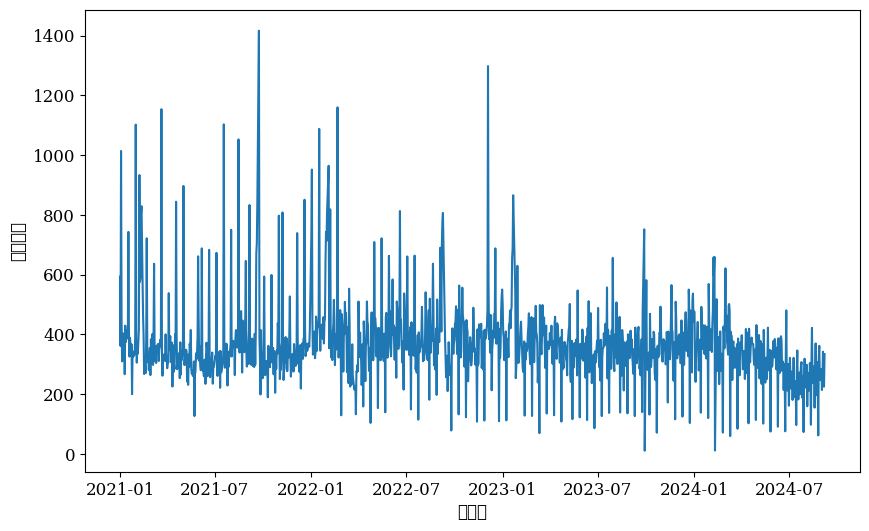

In [28]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data = df,x='매출일', y='매출수량',errorbar=None)
plt.show();

In [29]:
df['week'] = df['매출일'].dt.isocalendar().week
df['weekday'] = df['매출일'].dt.weekday
df['year'] = df['매출일'].dt.year
df['month'] = df['매출일'].dt.month
df

,매출일,매출수량,총매출채권금액,단가,week,weekday,year,month
3054,2021-01-01,30,44460,1482,53,4,2021,1
15781,2021-01-01,1704,2487840,1460,53,4,2021,1
27,2021-01-01,40,59280,1482,53,4,2021,1
4648,2021-01-01,204,297840,1460,53,4,2021,1
12351,2021-01-01,1,1482,1482,53,4,2021,1
...,...,...,...,...,...,...,...,...
7456,2024-09-06,3,6258,2086,36,4,2024,9
9668,2024-09-06,200,294000,1470,36,4,2024,9
8904,2024-09-06,50,101500,2030,36,4,2024,9
8551,2024-09-06,4,8624,2156,36,4,2024,9


In [30]:
df.weekday.value_counts()

,count
weekday,
4,15552
2,15552
5,15190
0,14316
3,14186
1,12786
6,4516


## 3년간 매출수량

In [31]:
y_grouped = df.groupby(['year','week','weekday'])['매출수량'].sum().reset_index()
y_grouped['wmy'] = y_grouped.year.astype('str') +'-'+ y_grouped.week.astype('str') +'-'+ y_grouped.weekday.astype('str')
y_grouped

,year,week,weekday,매출수량,wmy
0,2021,1,0,33579,2021-1-0
1,2021,1,1,22896,2021-1-1
2,2021,1,2,29101,2021-1-2
3,2021,1,3,21612,2021-1-3
4,2021,1,4,28188,2021-1-4
...,...,...,...,...,...
1322,2024,36,0,29789,2024-36-0
1323,2024,36,1,21193,2024-36-1
1324,2024,36,2,31240,2024-36-2
1325,2024,36,3,24931,2024-36-3


In [32]:
y_grouped[y_grouped.year ==2022]

,year,week,weekday,매출수량,wmy
361,2022,1,0,33885,2022-1-0
362,2022,1,1,23239,2022-1-1
363,2022,1,2,26605,2022-1-2
364,2022,1,3,23118,2022-1-3
365,2022,1,4,29888,2022-1-4
...,...,...,...,...,...
715,2022,52,2,30027,2022-52-2
716,2022,52,3,35415,2022-52-3
717,2022,52,4,44650,2022-52-4
718,2022,52,5,60583,2022-52-5


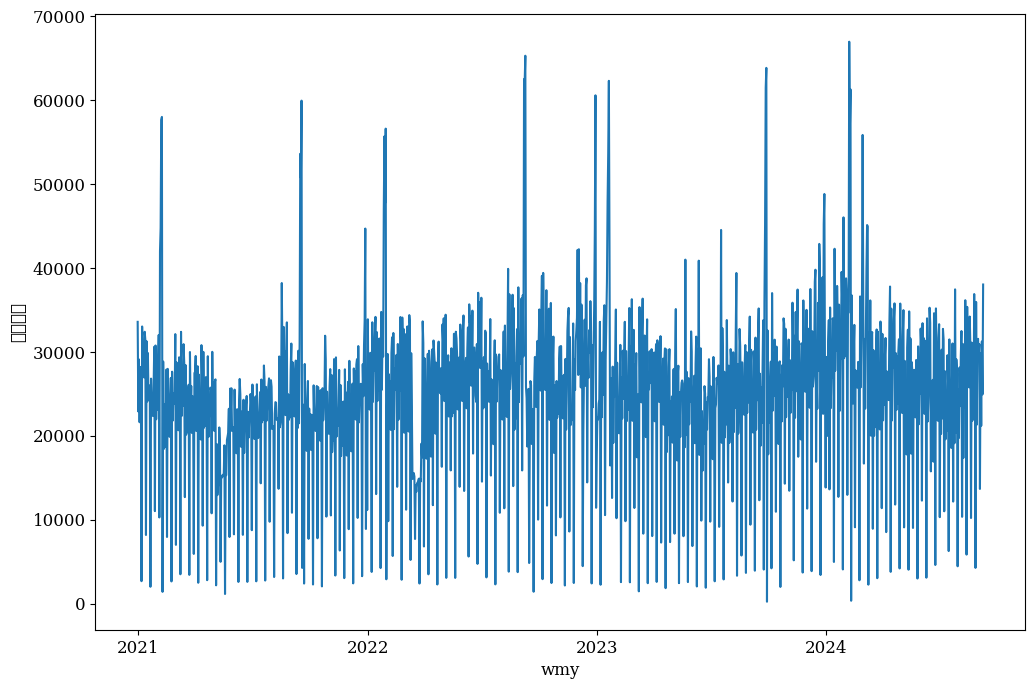

In [33]:


fig = plt.figure(figsize =(12,8))
sns.lineplot(data=y_grouped,x='wmy',y='매출수량')
plt.xticks([0, 361, 720,1079], ['2021','2022', '2023', '2024'])
plt.show()

In [34]:
grouped = df.groupby(['week','weekday'])['매출수량'].sum().reset_index()
grouped['wm'] =grouped.week.astype('str') +'-'+ grouped.weekday.astype('str')

grouped

,week,weekday,매출수량,wm
0,1,0,99130,1-0
1,1,1,97767,1-1
2,1,2,102900,1-2
3,1,3,88557,1-3
4,1,4,113737,1-4
...,...,...,...,...
362,52,5,109405,52-5
363,52,6,37968,52-6
364,53,4,8889,53-4
365,53,5,27443,53-5


## 같은시기 합계

In [35]:
grouped = df.groupby(['week','weekday'])['매출수량'].sum().reset_index()
grouped['wm'] =grouped.week.astype('str') +'-'+ grouped.weekday.astype('str')

grouped

,week,weekday,매출수량,wm
0,1,0,99130,1-0
1,1,1,97767,1-1
2,1,2,102900,1-2
3,1,3,88557,1-3
4,1,4,113737,1-4
...,...,...,...,...
362,52,5,109405,52-5
363,52,6,37968,52-6
364,53,4,8889,53-4
365,53,5,27443,53-5


In [36]:
def div(x):
  if x['wm']>'36-6':
    return x['매출수량']//3
  else:
    return x['매출수량']//4

In [37]:
grouped['평균매출수량'] = grouped.apply(div, axis=1)

In [38]:
grouped.to_csv('550.csv',index=False)

In [39]:
grouped

,week,weekday,매출수량,wm,평균매출수량
0,1,0,99130,1-0,24782
1,1,1,97767,1-1,24441
2,1,2,102900,1-2,25725
3,1,3,88557,1-3,22139
4,1,4,113737,1-4,28434
...,...,...,...,...,...
362,52,5,109405,52-5,36468
363,52,6,37968,52-6,12656
364,53,4,8889,53-4,2963
365,53,5,27443,53-5,9147


In [40]:
total_wm = len(grouped.wm)

550

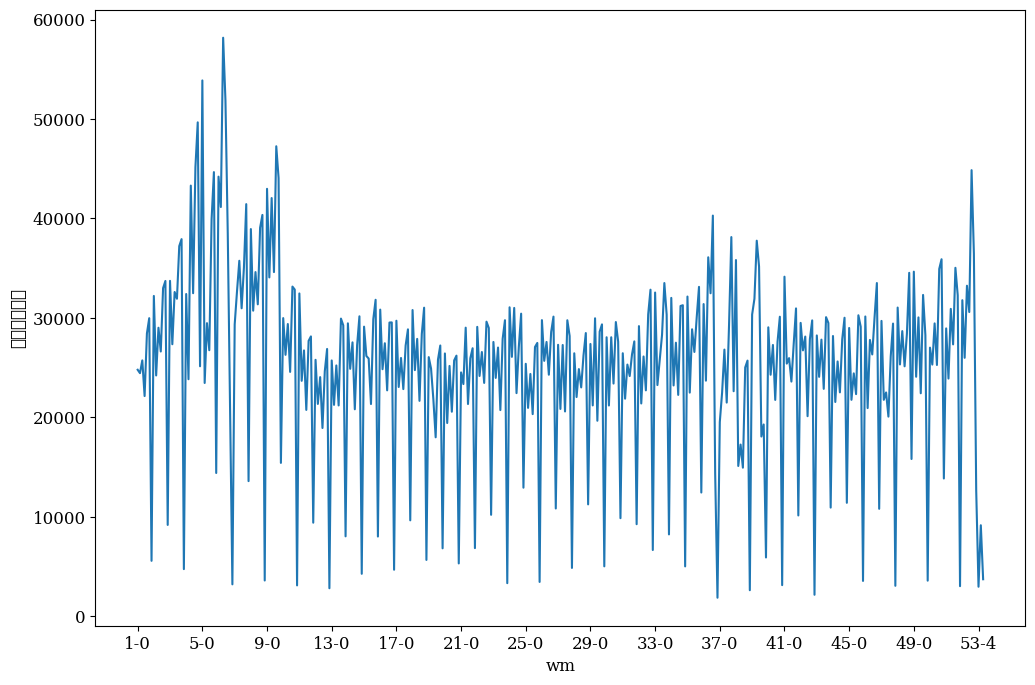

In [41]:
fig = plt.figure(figsize=(12,8))
sns.lineplot(data=grouped,x='wm',y='평균매출수량')
plt.xticks(np.arange(0,total_wm,28))
plt.show()

# Soup

In [42]:
soup2021 = pd.read_excel('/content/drive/MyDrive/erp/soup2021.xlsx')
soup2022 = pd.read_excel('/content/drive/MyDrive/erp/soup2022.xlsx')
soup2023 = pd.read_excel('/content/drive/MyDrive/erp/soup2023.xlsx')
soup2024 = pd.read_excel('/content/drive/MyDrive/erp/soup2024.xlsx')

In [43]:
df5 = soup2021.rename(columns=soup2021.iloc[2])
df5 = df5.drop(df5.index[0:3])
df6 = soup2022.rename(columns=soup2022.iloc[2])
df6 = df6.drop(df6.index[0:3])
df7 = soup2023.rename(columns=soup2023.iloc[2])
df7 = df7.drop(df7.index[0:3])
df8 = soup2024.rename(columns=soup2024.iloc[2])
df8 = df8.drop(df8.index[0:3])

In [44]:
df5.reset_index(drop=True, inplace=True)
df6.reset_index(drop=True, inplace=True)
df7.reset_index(drop=True, inplace=True)
df8.reset_index(drop=True, inplace=True)

In [45]:
df5['매출일'] = pd.to_datetime(df5['매출일'])
df6['매출일'] = pd.to_datetime(df6['매출일'])
df7['매출일'] = pd.to_datetime(df7['매출일'])
df8['매출일'] = pd.to_datetime(df8['매출일'])

In [46]:
df5 = df5[['매출일','매출수량','총매출채권금액']]
df6 = df6[['매출일','매출수량','총매출채권금액']]
df7 = df7[['매출일','매출수량','총매출채권금액']]
df8 = df8[['매출일','매출수량','총매출채권금액']]


In [47]:
soup2023 = df7.sort_values(by='매출일')
soup2023 = soup2023.groupby(['매출일'])['매출수량'].sum().reset_index()
soup2023['week'] = soup2023['매출일'].dt.isocalendar().week
soup2023['weekday'] = soup2023['매출일'].dt.weekday

In [48]:
soup2023

,매출일,매출수량,week,weekday
0,2023-04-20,2377,16,3
1,2023-04-21,569,16,4
2,2023-04-22,634,16,5
3,2023-04-23,246,16,6
4,2023-04-24,1318,17,0
...,...,...,...,...
138,2023-09-05,1712,36,1
139,2023-09-06,1615,36,2
140,2023-09-07,1459,36,3
141,2023-09-08,1738,36,4


In [49]:
soup2023.to_csv('soup2023.csv',index=False)

In [50]:
df_s = pd.concat([df5,df6,df7,df8])

In [51]:
df_s = df_s.sort_values(by='매출일')

In [52]:
zero_index = df_s[df_s['매출수량']==0].index
df_s.drop(zero_index,inplace=True)

In [53]:
df_s['단가'] = df_s['총매출채권금액']//df_s['매출수량']

In [54]:
df_s

,매출일,매출수량,총매출채권금액,단가
2313,2021-04-15,176,422242,2399
2463,2021-04-15,150,359865,2399
3222,2021-04-15,24,57578,2399
2566,2021-04-15,24,57578,2399
2377,2021-04-15,48,115157,2399
...,...,...,...,...
3183,2024-09-01,36,101574,2821
1839,2024-09-01,54,152361,2821
3151,2024-09-01,78,220077,2821
552,2024-09-01,204,575586,2821


In [55]:
pre_grouped_s = df_s.groupby(['매출일']).agg({'매출수량':'sum',
                                       '단가':lambda x: round(x.mean(),2)}).reset_index()
pre_grouped_s.columns = ['매출일', '총매출수량', '평균단가']
pre_grouped_s

,매출일,총매출수량,평균단가
0,2021-04-15,438,2399.00
1,2021-04-16,192,2399.00
2,2021-04-17,1950,2471.00
3,2021-04-18,144,2531.00
4,2021-04-19,1833,2393.13
...,...,...,...
542,2024-08-28,3351,2647.49
543,2024-08-29,3373,2683.52
544,2024-08-30,4464,2649.87
545,2024-08-31,4579,2661.23


In [56]:
#비어있는 날짜 0으로 처리
pre_grouped_s.set_index('매출일',inplace=True)
all_dates = pd.date_range(start='2021-01-01', end='2024-09-06', freq='D')

all_soup = pre_grouped_s.reindex(all_dates)

all_soup.fillna(0, inplace=True)
all_soup.index.name = '매출일'
n_soup = all_soup.reset_index()
n_soup.rename(columns={'index':'매출일'},inplace=True)
n_soup.drop(columns=['평균단가'], inplace=True)
n_soup.rename(columns={'총매출수량':'콩국물수량'},inplace=True)
n_soup

,매출일,콩국물수량
0,2021-01-01,0
1,2021-01-02,0
2,2021-01-03,0
3,2021-01-04,0
4,2021-01-05,0
...,...,...
1340,2024-09-02,0
1341,2024-09-03,0
1342,2024-09-04,0
1343,2024-09-05,0


In [57]:
n_soup[n_soup.매출일 == '2024-08-31']

,매출일,콩국물수량
1338,2024-08-31,4579


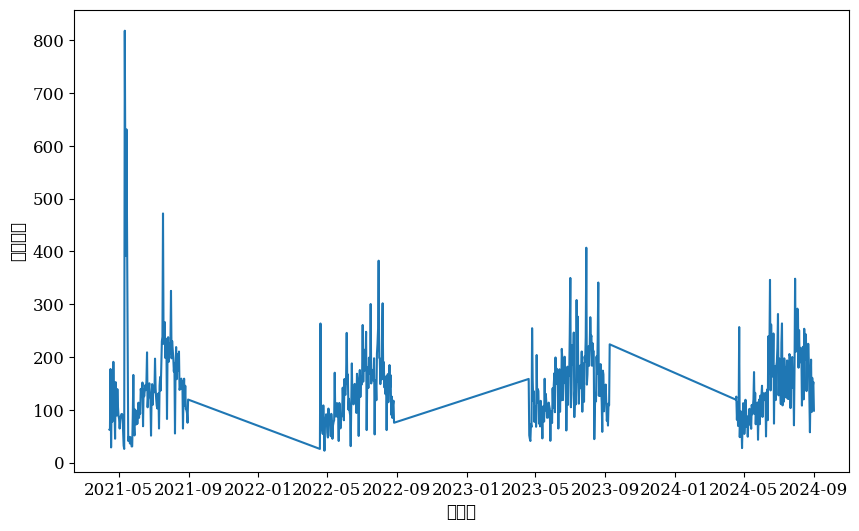

In [58]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data = df_s,x='매출일', y='매출수량',errorbar=None)
plt.show();

In [59]:
df_s['week'] = df_s['매출일'].dt.isocalendar().week
df_s['weekday'] = df_s['매출일'].dt.weekday
df_s['year'] = df_s['매출일'].dt.year
df_s['month'] = df_s['매출일'].dt.month
df_s

,매출일,매출수량,총매출채권금액,단가,week,weekday,year,month
2313,2021-04-15,176,422242,2399,15,3,2021,4
2463,2021-04-15,150,359865,2399,15,3,2021,4
3222,2021-04-15,24,57578,2399,15,3,2021,4
2566,2021-04-15,24,57578,2399,15,3,2021,4
2377,2021-04-15,48,115157,2399,15,3,2021,4
...,...,...,...,...,...,...,...,...
3183,2024-09-01,36,101574,2821,35,6,2024,9
1839,2024-09-01,54,152361,2821,35,6,2024,9
3151,2024-09-01,78,220077,2821,35,6,2024,9
552,2024-09-01,204,575586,2821,35,6,2024,9


In [60]:
df_s[df_s['매출일']=='2024-09-01']

,매출일,매출수량,총매출채권금액,단가,week,weekday,year,month
3183,2024-09-01,36,101574,2821,35,6,2024,9
1839,2024-09-01,54,152361,2821,35,6,2024,9
3151,2024-09-01,78,220077,2821,35,6,2024,9
552,2024-09-01,204,575586,2821,35,6,2024,9
3755,2024-09-01,120,338580,2821,35,6,2024,9


In [61]:
y_grouped_s = df_s.groupby(['year','week','weekday'])['매출수량'].sum().reset_index()
y_grouped_s['wmy'] = y_grouped_s.year.astype('str') +'-'+ y_grouped_s.week.astype('str') +'-'+ y_grouped_s.weekday.astype('str')
y_grouped_s

,year,week,weekday,매출수량,wmy
0,2021,15,3,438,2021-15-3
1,2021,15,4,192,2021-15-4
2,2021,15,5,1950,2021-15-5
3,2021,15,6,144,2021-15-6
4,2021,16,0,1833,2021-16-0
...,...,...,...,...,...
542,2024,35,2,3351,2024-35-2
543,2024,35,3,3373,2024-35-3
544,2024,35,4,4464,2024-35-4
545,2024,35,5,4579,2024-35-5


In [62]:
y_grouped_s[y_grouped_s.year == 2022]

,year,week,weekday,매출수량,wmy
135,2022,16,1,390,2022-16-1
136,2022,16,2,5006,2022-16-2
137,2022,16,3,1926,2022-16-3
138,2022,16,4,1766,2022-16-4
139,2022,16,5,1192,2022-16-5
...,...,...,...,...,...
261,2022,34,1,3377,2022-34-1
262,2022,34,2,3052,2022-34-2
263,2022,34,3,2825,2022-34-3
264,2022,34,4,3050,2022-34-4


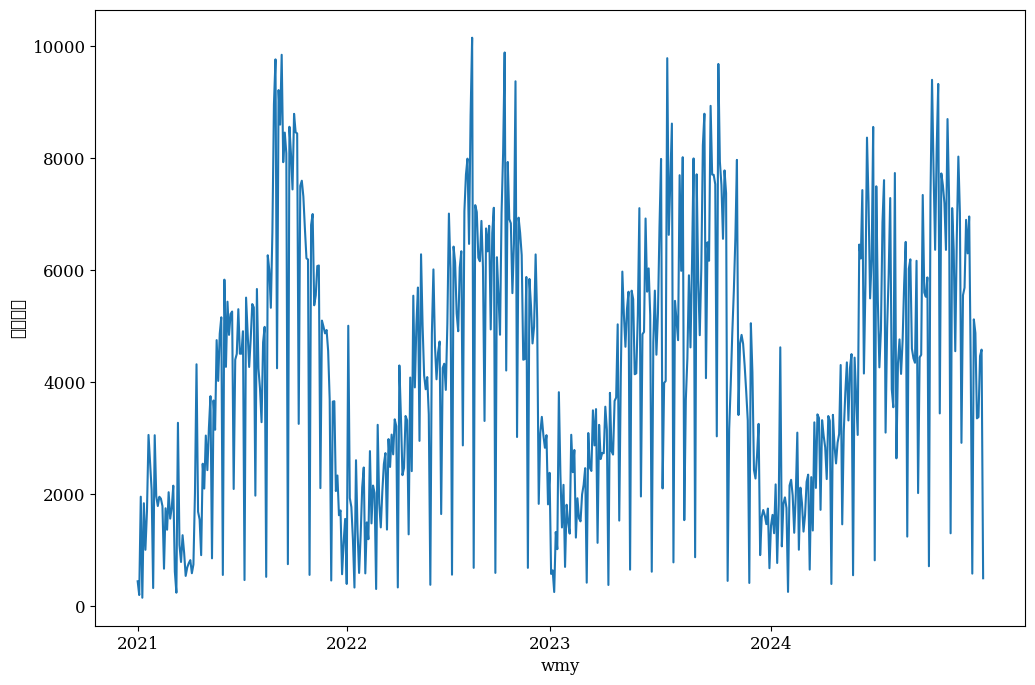

In [63]:
fig = plt.figure(figsize =(12,8))
sns.lineplot(data=y_grouped_s,x='wmy',y='매출수량')
plt.xticks([0, 135, 266, 409], ['2021','2022', '2023', '2024'])
plt.show()

In [64]:
grouped_s = df_s.groupby(['week','weekday'])['매출수량'].sum().reset_index()
grouped_s['평균매출수량'] = grouped_s['매출수량'] //4
grouped_s['wm'] =grouped_s.week.astype('str') +'-'+ grouped_s.weekday.astype('str')

grouped_s

,week,weekday,매출수량,평균매출수량,wm
0,15,3,438,109,15-3
1,15,4,192,48,15-4
2,15,5,1950,487,15-5
3,15,6,144,36,15-6
4,16,0,1833,458,16-0
...,...,...,...,...,...
145,36,1,1712,428,36-1
146,36,2,1615,403,36-2
147,36,3,1459,364,36-3
148,36,4,1738,434,36-4


In [65]:
grouped_s[grouped_s['wm']=='32-6']

,week,weekday,매출수량,평균매출수량,wm
122,32,6,4522,1130,32-6


In [66]:
grouped_s.to_csv('soup.csv',index=False)

In [67]:
total_wm_s = len(grouped_s.wm)

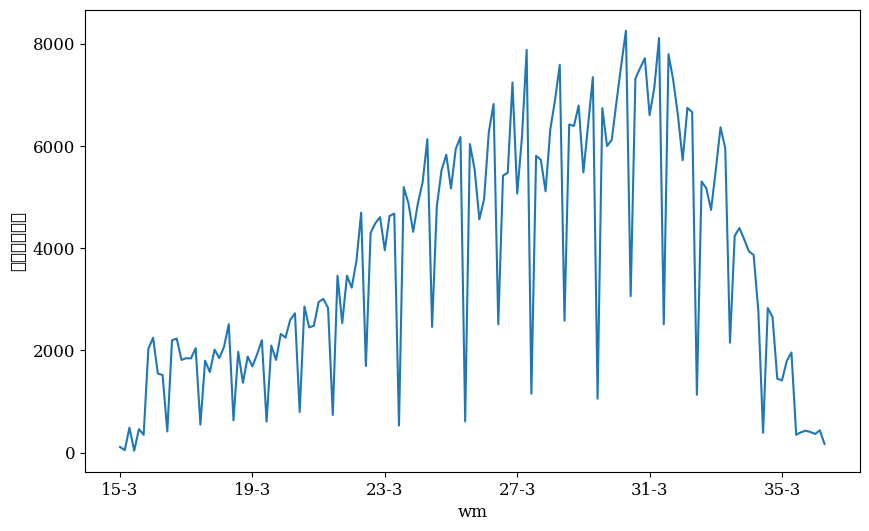

In [68]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=grouped_s,x='wm',y='평균매출수량')
plt.xticks(np.arange(0,total_wm_s,28))
plt.show();

In [69]:
import matplotlib.font_manager as fm

# 사용 가능한 폰트 목록 확인
for font in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    print(fm.FontProperties(fname=font).get_name())

Liberation Mono
Liberation Sans
NanumBarunGothic
NanumSquareRound
NanumBarunGothic
Liberation Sans
Liberation Serif
Liberation Sans Narrow
NanumMyeongjo
Liberation Mono
NanumSquare
NanumGothicCoding
Liberation Mono
Humor Sans
Liberation Serif
Liberation Mono
NanumSquareRound
Liberation Sans
NanumGothicCoding
NanumGothic
NanumMyeongjo
NanumGothic
Liberation Serif
Liberation Sans Narrow
Liberation Serif
Liberation Sans
Liberation Sans Narrow
NanumSquare
Liberation Sans Narrow


In [70]:
rainfall = pd.read_csv('/content/drive/MyDrive/erp/rn_20240919164059.csv',
                 header=None,        # 기존 헤더를 무시하고 직접 컬럼명 지정
                 names=['날짜', '지점', '강수량(mm)'],  # 컬럼명 지정
                 index_col=False,    # 인덱스 열을 지정하지 않음
                 parse_dates=['날짜'], # 날짜 열을 날짜 형식으로 변환
                 na_values=[''],
                 encoding='cp949')

temp = pd.read_csv('/content/drive/MyDrive/erp/ta_20240919164028.csv',
                 header=None,  # 첫 번째 행을 무시하고 직접 컬럼명 지정
                 names=['날짜', '지점', '평균기온(℃)', '최저기온(℃)', '최고기온(℃)'],  # 컬럼명 지정
                 index_col=False,  # 인덱스 열을 별도로 지정하지 않음
                 parse_dates=['날짜'],  # 날짜 형식을 파싱
                 na_values=[''],  # 빈 값 처리
                 skipinitialspace=True,
                 encoding='cp949')
rainfall

,날짜,지점,강수량(mm)
0,강수분석,NaN,NaN
1,[검색조건],NaN,NaN
2,자료구분 : 일,NaN,NaN
3,자료형태 : 기본,NaN,NaN
4,지역/지점 : 서울,NaN,NaN
...,...,...,...
1347,2024-09-02,108,2.7
1348,2024-09-03,108,NaN
1349,2024-09-04,108,NaN
1350,2024-09-05,108,6.9


In [71]:
tp = temp.drop(temp.index[0:7])
tp.reset_index(drop=True,inplace=True)
tp = tp.fillna(0)
rf = rainfall.drop(rainfall.index[0:7])
rf.reset_index(drop=True,inplace=True)
rf = rf.fillna(0)
rf

,날짜,지점,강수량(mm)
0,2021-01-01,108,0
1,2021-01-02,108,0
2,2021-01-03,108,0
3,2021-01-04,108,0
4,2021-01-05,108,0
...,...,...,...
1340,2024-09-02,108,2.7
1341,2024-09-03,108,0
1342,2024-09-04,108,0
1343,2024-09-05,108,6.9


In [72]:
tp['날짜'] = tp['날짜'].astype(str).str.replace('\t','')
tp['날짜'] = pd.to_datetime(tp['날짜'], format='%Y-%m-%d')
tp['평균기온(℃)'] = tp['평균기온(℃)'].astype(float)
tp['최저기온(℃)'] = tp['최저기온(℃)'].astype(float)
tp['최고기온(℃)'] = tp['최고기온(℃)'].astype(float)
rf['날짜'] = pd.to_datetime(rf['날짜'], format='%Y-%m-%d')
rf['강수량(mm)'] = rf['강수량(mm)'].astype(float)



rf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1345 entries, 0 to 1344
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   날짜       1345 non-null   datetime64[ns]
 1   지점       1345 non-null   object        
 2   강수량(mm)  1345 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 31.6+ KB


In [73]:
rf['강수bool'] = rf['강수량(mm)'].apply(lambda x: 0 if x == 0 else 1)

In [74]:
rf

,날짜,지점,강수량(mm),강수bool
0,2021-01-01,108,0.0,0
1,2021-01-02,108,0.0,0
2,2021-01-03,108,0.0,0
3,2021-01-04,108,0.0,0
4,2021-01-05,108,0.0,0
...,...,...,...,...
1340,2024-09-02,108,2.7,1
1341,2024-09-03,108,0.0,0
1342,2024-09-04,108,0.0,0
1343,2024-09-05,108,6.9,1


In [75]:
climate = pd.merge(tp,rf,on=['날짜','지점'],how='left')
climate = climate.drop(columns=['지점'])
climate

,날짜,평균기온(℃),최저기온(℃),최고기온(℃),강수량(mm),강수bool
0,2021-01-01,-4.2,-9.8,1.6,0.0,0
1,2021-01-02,-5.0,-8.4,-1.4,0.0,0
2,2021-01-03,-5.6,-9.1,-2.0,0.0,0
3,2021-01-04,-3.5,-8.4,0.3,0.0,0
4,2021-01-05,-5.5,-9.9,-2.1,0.0,0
...,...,...,...,...,...,...
1340,2024-09-02,24.5,22.2,26.9,2.7,1
1341,2024-09-03,27.0,23.2,32.0,0.0,0
1342,2024-09-04,27.9,23.2,33.3,0.0,0
1343,2024-09-05,26.3,25.6,28.8,6.9,1


In [76]:
pre_grouped

,매출일,총매출수량,평균단가
0,2021-01-01,8889,1442.80
1,2021-01-02,27443,1270.63
2,2021-01-03,11149,1423.82
3,2021-01-04,33579,1264.05
4,2021-01-05,22896,1275.65
...,...,...,...
1324,2024-09-02,29789,1738.45
1325,2024-09-03,21193,1593.77
1326,2024-09-04,31240,1786.39
1327,2024-09-05,24931,1836.41


In [77]:
new_df = pd.merge(climate,pre_grouped,left_on=['날짜'],right_on=['매출일'])


In [78]:
new_df = new_df.drop(columns=['매출일'])
new_df

,날짜,평균기온(℃),최저기온(℃),최고기온(℃),강수량(mm),강수bool,총매출수량,평균단가
0,2021-01-01,-4.2,-9.8,1.6,0.0,0,8889,1442.80
1,2021-01-02,-5.0,-8.4,-1.4,0.0,0,27443,1270.63
2,2021-01-03,-5.6,-9.1,-2.0,0.0,0,11149,1423.82
3,2021-01-04,-3.5,-8.4,0.3,0.0,0,33579,1264.05
4,2021-01-05,-5.5,-9.9,-2.1,0.0,0,22896,1275.65
...,...,...,...,...,...,...,...,...
1324,2024-09-02,24.5,22.2,26.9,2.7,1,29789,1738.45
1325,2024-09-03,27.0,23.2,32.0,0.0,0,21193,1593.77
1326,2024-09-04,27.9,23.2,33.3,0.0,0,31240,1786.39
1327,2024-09-05,26.3,25.6,28.8,6.9,1,24931,1836.41


In [79]:
# X = final_df[['날짜','평균기온(℃)','최저기온(℃)','최고기온(℃)','강수량(mm)','강수bool','평균단가']]
# Y = final_df['총매출수량']
# X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

In [80]:
import requests
import pprint
import json

url = 'http://apis.data.go.kr/1360000/AsosDalyInfoService/getWthrDataList'
params ={'serviceKey' : '0ugQ4AGF76S72YECTC1qiZKWP6XZALIW+UPlkc0wnolNxDyY6S2rU7/0HKK5KqHh4k+r6FfRWtWAdG+7+FEDdg==', 'pageNo' : '2', 'numOfRows' : '10', 'dataType' : 'json', 'dataCd' : 'ASOS', 'dateCd' : 'DAY', 'startDt' : '20240925', 'endDt' : '20240925', 'stnIds' : '108' }

response = requests.get(url, params=params)
pp = pprint.PrettyPrinter(indent=4)
print(pp.pprint(response.content))


(b'{"response":{"header":{"resultCode":"00","resultMsg":"NORMAL_SERVICE"},"body'
 b'":{"dataType":"JSON","items":{"item":[{"stnId":"108","stnNm":"\xec\x84'
 b'\x9c\xec\x9a\xb8","tm":"2024-09-25","avgTa":"23.3","minTa":"18.6","minTaHrmt'
 b'":"0312","maxTa":"27.3","maxTaHrmt":"1424","mi10MaxRn":"0.0","mi10MaxRnHrmt"'
 b':"","hr1MaxRn":"0.0","hr1MaxRnHrmt":"","sumRnDur":"0.5","sumRn":"0.0","maxIn'
 b'sWs":"5.8","maxInsWsWd":"50","maxInsWsHrmt":"0441","maxWs":"3.2","maxWsWd":"'
 b'50","maxWsHrmt":"0608","avgWs":"1.7","hr24SumRws":"1448","maxWd":"70","avgTd'
 b'":"16.3","minRhm":"55","minRhmHrmt":"1432","avgRhm":"65.6","avgPv":"18.7","a'
 b'vgPa":"1003.8","maxPs":"1015.5","maxPsHrmt":"0922","minPs":"1011.9","minPsHr'
 b'mt":"1538","avgPs":"1013.6","ssDur":"12.0","sumSsHr":"6.1","hr1MaxIcsrHrmt":'
 b'"1100","hr1MaxIcsr":"2.65","sumGsr":"13.51","ddMefs":"","ddMefsHrmt":"","ddM'
 b'es":"","ddMesHrmt":"","sumDpthFhsc":"","avgTca":"5.8","avgLmac":"4.3","avgTs'
 b'":"21.8","minTg":"14.3","avgCm5

In [81]:
import requests

url = 'https://www.weather.go.kr/w/index.do'
response = requests.get(url)
html = response.text

In [82]:
from bs4 import BeautifulSoup

soup =  BeautifulSoup(html,'html.parser')

daily_slides = soup.find_all('div', class_='dfs-daily-slide')

daily_slides

[]

# 습도

In [83]:
rainfall = pd.read_csv('/content/drive/MyDrive/erp/rn_20240919164059.csv',
                 header=None,        # 기존 헤더를 무시하고 직접 컬럼명 지정
                 names=['날짜', '지점', '강수량(mm)'],  # 컬럼명 지정
                 index_col=False,    # 인덱스 열을 지정하지 않음
                 parse_dates=['날짜'], # 날짜 열을 날짜 형식으로 변환
                 na_values=[''],
                 encoding='cp949')

In [84]:
humid = pd.read_csv('/content/drive/MyDrive/erp/extremum_20240930142901.csv',
                 header=None,
                 names=['지점번호','지점명','일시','평균습도','최저습도'],
                 index_col=False,
                 parse_dates=['일시'],
                 na_values=[''],
                 encoding='cp949',
                 skipinitialspace=True)
humid

,지점번호,지점명,일시,평균습도,최저습도
0,조건별분석,NaN,NaN,NaN,NaN
1,[검색조건],NaN,NaN,NaN,NaN
2,NaN,분류: 지상,NaN,NaN,NaN
3,NaN,요소 : 습도,NaN,NaN,NaN
4,NaN,검색구분 : 일,NaN,NaN,NaN
...,...,...,...,...,...
1371,\t\t108,서울,2024-09-25,65.6,55.0
1372,\t\t108,서울,2024-09-26,75.1,57.0
1373,\t\t108,서울,2024-09-27,72.8,49.0
1374,\t\t108,서울,2024-09-28,59.3,48.0


In [85]:
hm = humid.drop(humid.index[0:8])
hm['지점번호'] = hm['지점번호'].str.replace('\t','')
hm['일시'] = pd.to_datetime(hm['일시'], format='%Y-%m-%d')
n_hm = hm[hm['일시']<='2024-09-06']
n_hm = n_hm[['일시','평균습도','최저습도']]
n_hm['최저습도']=n_hm['최저습도'].astype(float)
n_hm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1345 entries, 8 to 1352
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   일시      1345 non-null   datetime64[ns]
 1   평균습도    1345 non-null   object        
 2   최저습도    1345 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 42.0+ KB


In [86]:
final_df = pd.merge(new_df,n_hm,left_on='날짜',right_on='일시')
final_df.drop(columns=['일시'],inplace=True)
final_df['weekday'] = final_df.날짜.dt.isocalendar().week.astype('str') +  final_df.날짜.dt.weekday.astype('str')
final_df['day'] = final_df.날짜.dt.isocalendar().day

In [87]:
final_df

,날짜,평균기온(℃),최저기온(℃),최고기온(℃),강수량(mm),강수bool,총매출수량,평균단가,평균습도,최저습도,weekday,day
0,2021-01-01,-4.2,-9.8,1.6,0.0,0,8889,1442.80,64.0,50.0,534,5
1,2021-01-02,-5.0,-8.4,-1.4,0.0,0,27443,1270.63,38.5,29.0,535,6
2,2021-01-03,-5.6,-9.1,-2.0,0.0,0,11149,1423.82,45.0,28.0,536,7
3,2021-01-04,-3.5,-8.4,0.3,0.0,0,33579,1264.05,51.4,38.0,10,1
4,2021-01-05,-5.5,-9.9,-2.1,0.0,0,22896,1275.65,52.8,30.0,11,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1324,2024-09-02,24.5,22.2,26.9,2.7,1,29789,1738.45,73.6,65.0,360,1
1325,2024-09-03,27.0,23.2,32.0,0.0,0,21193,1593.77,54.5,44.0,361,2
1326,2024-09-04,27.9,23.2,33.3,0.0,0,31240,1786.39,61.4,42.0,362,3
1327,2024-09-05,26.3,25.6,28.8,6.9,1,24931,1836.41,79.1,63.0,363,4


In [88]:
s_finaldf = pd.merge(final_df,n_soup, left_on='날짜',right_on='매출일')
s_finaldf.weekday = s_finaldf.weekday.astype(int)
s_finaldf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1329 entries, 0 to 1328
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   날짜       1329 non-null   datetime64[ns]
 1   평균기온(℃)  1329 non-null   float64       
 2   최저기온(℃)  1329 non-null   float64       
 3   최고기온(℃)  1329 non-null   float64       
 4   강수량(mm)  1329 non-null   float64       
 5   강수bool   1329 non-null   int64         
 6   총매출수량    1329 non-null   object        
 7   평균단가     1329 non-null   float64       
 8   평균습도     1329 non-null   object        
 9   최저습도     1329 non-null   float64       
 10  weekday  1329 non-null   int64         
 11  day      1329 non-null   UInt32        
 12  매출일      1329 non-null   datetime64[ns]
 13  콩국물수량    1329 non-null   int64         
dtypes: UInt32(1), datetime64[ns](2), float64(6), int64(3), object(2)
memory usage: 141.6+ KB


In [89]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1329 entries, 0 to 1328
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   날짜       1329 non-null   datetime64[ns]
 1   평균기온(℃)  1329 non-null   float64       
 2   최저기온(℃)  1329 non-null   float64       
 3   최고기온(℃)  1329 non-null   float64       
 4   강수량(mm)  1329 non-null   float64       
 5   강수bool   1329 non-null   int64         
 6   총매출수량    1329 non-null   object        
 7   평균단가     1329 non-null   float64       
 8   평균습도     1329 non-null   object        
 9   최저습도     1329 non-null   float64       
 10  weekday  1329 non-null   object        
 11  day      1329 non-null   UInt32        
dtypes: UInt32(1), datetime64[ns](1), float64(6), int64(1), object(3)
memory usage: 120.8+ KB


In [90]:
final_df['weekday'] = final_df['weekday'].astype(int)

# 데이터 분리

In [91]:
#기존
split_index = int(len(final_df)*0.8)
train_data =  final_df.iloc[:split_index]
test_data = final_df.iloc[split_index:]
x_train = train_data[['최저기온(℃)','최고기온(℃)','최저습도','weekday','day']]
y_train = train_data['총매출수량']
x_test = test_data[['최저기온(℃)','최고기온(℃)','최저습도','weekday','day']]
y_test = test_data['총매출수량']

In [92]:
#콩국물
s_split_index = int(len(s_finaldf)*0.8)
s_train_data =  s_finaldf.iloc[:split_index]
s_test_data = s_finaldf.iloc[split_index:]
s_train = s_train_data[['최저기온(℃)','최고기온(℃)','최저습도','weekday','day']]
p_train = s_train_data['콩국물수량']
s_test = s_test_data[['최저기온(℃)','최고기온(℃)','최저습도','weekday','day']]
p_test = s_test_data['콩국물수량']

In [93]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1063 entries, 0 to 1062
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   최저기온(℃)  1063 non-null   float64
 1   최고기온(℃)  1063 non-null   float64
 2   최저습도     1063 non-null   float64
 3   weekday  1063 non-null   int64  
 4   day      1063 non-null   UInt32 
dtypes: UInt32(1), float64(3), int64(1)
memory usage: 38.5 KB


In [94]:
# x = final_df[['최저기온(℃)','최고기온(℃)','평균단가','최저습도','weekday']]
# y = final_df['총매출수량']
# x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)
# x.info()

In [95]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

#fit을 통해 데이터의 평균과 표준편차를 계산하기 때문에 x_train에는 fit_transform, x_test에는 transform을 실행한다.
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [96]:
x_train_scaled

array([[0.18965517, 0.26059322, 0.44047619, 0.99619772, 0.66666667],
       [0.21982759, 0.1970339 , 0.19047619, 0.99809886, 0.83333333],
       [0.20474138, 0.18432203, 0.17857143, 1.        , 1.        ],
       ...,
       [0.50862069, 0.48728814, 0.63095238, 0.93155894, 0.        ],
       [0.4762931 , 0.42372881, 0.53571429, 0.93346008, 0.16666667],
       [0.45689655, 0.44491525, 0.57142857, 0.93536122, 0.33333333]])

In [97]:
model = XGBRegressor()
model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [98]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1063 entries, 0 to 1062
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   최저기온(℃)  1063 non-null   float64
 1   최고기온(℃)  1063 non-null   float64
 2   최저습도     1063 non-null   float64
 3   weekday  1063 non-null   int64  
 4   day      1063 non-null   UInt32 
dtypes: UInt32(1), float64(3), int64(1)
memory usage: 38.5 KB


In [99]:
s_model = XGBRegressor()
s_model.fit(s_train, p_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [100]:
y_pred = model.predict(x_test)

## 기준모델

In [101]:
y_mean = y_test.mean()

In [102]:
p_mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
n_mape = np.mean(np.abs((y_test - y_mean) / y_test)) * 100
p_mae = mean_absolute_error(y_test, y_pred)
p_mse = mean_squared_error(y_test, y_pred)
n_mae = mean_absolute_error(y_test, [y_mean]*len(y_test))
n_mse = mean_squared_error(y_test, [y_mean]*len(y_test))

In [103]:
n_mape

93.42063194597354

In [104]:
#mape의 값으로 볼때 데이터 자체의 오차가 상당히 크다
# 오늘의 가격과 기온으로 매출량 예측 (새로운 데이터)
# new_data = pd.DataFrame({'가격': [600], '기온': [12]})  # 새로운 가격과 기온
# predicted_sales = model.predict(new_data)

# print(f"오늘의 예측 매출량: {predicted_sales[0]}")

In [105]:
import pickle

with open('xgboost.pickle','wb') as fw:
  pickle.dump(model,fw)

In [106]:
from datetime import datetime

today = datetime.today().strftime('%Y%m%d')

url = 'https://apihub.kma.go.kr/api/typ01/url/kma_sfcdd.php?tm=20240831&stn=0&help=1&authKey=ROaULZ0vTjGmlC2dL64xFg'
response = requests.get(url)
res_txt = response.text
lines = res_txt.strip().split('\n')
data_rows = [line.split() for line in lines]
data = data_rows[4:-1]
data_clean = []
for i in data[61:]:
  data_clean.append(i[0].rstrip(',').split(','))

for line_number, line in enumerate(lines):
        if '01234567890123456789' in line:
            endline = line_number-1
            break
header_rows = [line.split() for line in lines[4:endline]]
header=[]
for i in header_rows:
    header.append(i[2])

df_c = pd.DataFrame(data_clean, columns=header)
df_c[['STN','TA_AVG','TA_MAX','TA_MIN','RN_DAY','HM_AVG','HM_MIN']]

for i in data_clean:
  if i[1] =='108':
    TA_MAX = i[11]
    TA_MIN = i[13]
    HM_MIN = i[19]


In [107]:
df_c[['STN','TA_AVG','TA_MAX','TA_MIN','RN_DAY','HM_AVG','HM_MIN']]


,STN,TA_AVG,TA_MAX,TA_MIN,RN_DAY,HM_AVG,HM_MIN
0,90,24.6,29.1,20.7,-9.0,72.8,54.0
1,93,24.7,32.2,18.5,-9.0,76.4,42.0
2,95,24.2,31.4,17.8,-9.0,77.9,41.0
3,98,25.0,32.1,19.7,-9.0,79.6,48.0
4,99,24.5,31.4,18.6,-9.0,83.4,49.0
...,...,...,...,...,...,...,...
92,288,27.8,34.3,21.7,-9.0,60.5,28.0
93,289,27.0,33.6,20.3,-9.0,72.1,41.0
94,294,26.9,32.4,22.8,-9.0,72.8,44.0
95,295,26.9,33.5,22.6,-9.0,68.9,34.0


In [108]:
thisday = datetime.today()
week_number = datetime(2024,8,31).isocalendar().week
weekday_number = datetime(2024,8,31).isocalendar().weekday
col_weekday = int(f'{week_number}{weekday_number}')


today_data = pd.DataFrame({
    '최저기온(℃)':[float(TA_MIN)],
    '최고기온(℃)':[float(TA_MAX)],
    # '평균단가':[float(1800)],
    '최저습도':[float(HM_MIN)],
    'weekday':[col_weekday],
    'day':[weekday_number]
})


In [109]:
TA_MIN

'22.6'

In [110]:
today_data

,최저기온(℃),최고기온(℃),최저습도,weekday,day
0,22.6,33.0,40.0,356,6


In [111]:
predicted_sales = model.predict(today_data)

In [112]:
s_predicted_sales = s_model.predict(today_data)

In [113]:
s_predicted_sales[0]

1148.0261

In [114]:
predicted_sales[0]

33184.23

In [115]:
s1006 = pd.read_excel('/content/drive/MyDrive/erp/1002.xlsx')
n1006 = s1006.rename(columns=s1006.iloc[2])
n1006.drop(n1006.index[0:3],inplace=True)
n1006.reset_index(drop=True,inplace=True)
n1006.매출수량.sum()

27747

In [116]:
importance = model.feature_importances_
s_importance = s_model.feature_importances_

In [117]:
importances = pd.DataFrame()
importances['feature'] = x_train.columns
importances['importance'] = importance
importances.sort_values(by='importance',ascending=False, inplace=True)



In [118]:
s_importances = pd.DataFrame()
s_importances['feature'] = s_train.columns
s_importances['importance'] = s_importance
s_importances.sort_values(by='importance',ascending=False, inplace=True)

<Axes: xlabel='importance', ylabel='feature'>

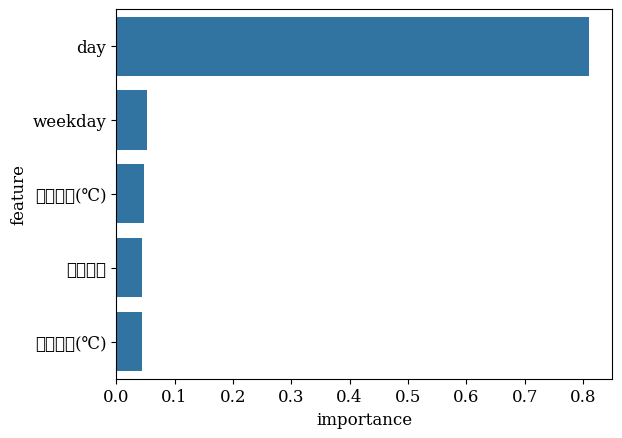

In [119]:
sns.barplot(data = importances,x='importance', y='feature')

In [120]:
s_importances

,feature,importance
0,최저기온(℃),0.389435
3,weekday,0.281410
4,day,0.239296
1,최고기온(℃),0.072834
2,최저습도,0.017025


In [121]:
s_train

,최저기온(℃),최고기온(℃),최저습도,weekday,day
0,-9.8,1.6,50.0,534,5
1,-8.4,-1.4,29.0,535,6
2,-9.1,-2.0,28.0,536,7
3,-8.4,0.3,38.0,10,1
4,-9.9,-2.1,30.0,11,2
...,...,...,...,...,...
1058,11.7,16.2,70.0,495,6
1059,6.7,15.5,46.0,496,7
1060,5.0,12.3,66.0,500,1
1061,3.5,9.3,58.0,501,2


<Axes: xlabel='importance', ylabel='feature'>

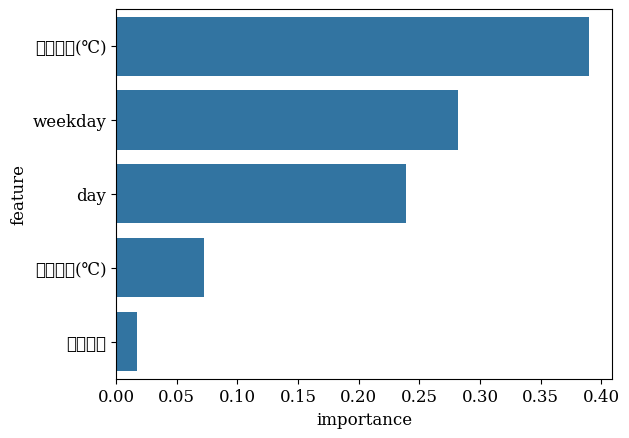

In [122]:
sns.barplot(data = s_importances, x='importance', y= 'feature')

In [137]:
s1007 = pd.read_excel('/content/drive/MyDrive/erp/1008.xlsx')
n1007 = s1007.rename(columns=s1007.iloc[2])
n1007.drop(n1007.index[0:3],inplace=True)
n1007.reset_index(drop=True,inplace=True)

In [138]:
oo01007 = n1007[n1007.품목명 == '초당 포장두부550g']
oo01007.매출수량.sum()

17795

In [124]:
cup_filter = n1007['품목명'].str.contains('컵순두부')
cup = n1007[cup_filter]
temp = cup[cup.발행처명 == '갤러리아 센터시티점']
temp = temp.sort_values(by='매출일')
temp.매출일

,매출일
39918,2024-01-06 00:00:00
24549,2024-01-11 00:00:00
47097,2024-01-16 00:00:00
49169,2024-01-20 00:00:00
47759,2024-01-30 00:00:00
35248,2024-02-17 00:00:00
35251,2024-02-20 00:00:00
43087,2024-03-02 00:00:00
36232,2024-03-14 00:00:00
36233,2024-03-21 00:00:00
